## **<h3 style="color:#0066cc;">Predicting Heart Disease - A Comparative ML Analysis</h3>**
<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**Binary Classification | GridSearchCV Tuning | SHAP & LIME Explainability | 5 Models**</span>

</div>

**Author:** Fellah Hanane  
**Dataset:** Heart Disease Prediction : 270 patients, 14 clinical features  
**Goal:** Predict the presence or absence of heart disease from clinical measurements, enabling early diagnosis and prioritization of high-risk patients.

---

### Table of Contents
1. [Problem Statement](#1)
2. [Dataset Loading & Description](#2)
3. [Exploratory Data Analysis](#3)
4. [Preprocessing](#4)
5. [Baseline Models](#5)
6. [Hyperparameter Tuning](#6)
7. [Full Model Comparison](#7)
8. [Results & Visualizations](#8)
9. [SHAP & LIME Explainability](#9)
10. [Conclusion](#10)

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**1. Problem Statement <a id='1'></a>**</span>

</div>

Heart disease is the leading cause of death globally, responsible for approximately 17.9 million deaths per year according to the WHO. Early detection is critical, patients identified as high-risk can receive timely interventions that significantly improve survival outcomes.

This notebook builds and compares multiple machine learning models that predict heart disease from routine clinical measurements. The goal is not just to find the most accurate model, but also to understand **which clinical features drive each prediction** using SHAP and LIME explainability.

**This is a binary classification problem:**

| Class | Meaning | Clinical Action |
|---|---|---|
| `Absence` | No heart disease detected | Routine monitoring |
| `Presence` | Heart disease present | Immediate clinical intervention |

> **Clinical priority:** A false negative (missing a sick patient) is far more dangerous than a false positive. I therefore pay close attention to **recall for the Presence class** alongside overall accuracy.

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**2. Dataset Loading & Description <a id='2'></a>**</span>

</div>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from xgboost import XGBClassifier
import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


**Loading the dataset.** The dataset is sourced from Kaggle (`rishidamarla/heart-disease-prediction`). If running locally without a Kaggle account, place the CSV file in the same directory and load with `pd.read_csv("Heart_Disease_Prediction.csv")`.

In [5]:
import kagglehub
import os # the operating system, it’s used to build file paths in a way that works on all systems (Windows, macOS, Linux).
import pandas as pd

path = kagglehub.dataset_download("rishidamarla/heart-disease-prediction")
file_path = os.path.join(path, 'Heart_Disease_Prediction.csv')
data = pd.read_csv(file_path)
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### Feature Description

| Feature | Type | Description |
|---|---|---|
| `Age` | Numerical | Patient age in years |
| `Sex` | Binary | 1 = Male, 0 = Female |
| `Chest pain type` | Categorical | 1=Typical angina, 2=Atypical, 3=Non-anginal, 4=Asymptomatic |
| `BP` | Numerical | Resting blood pressure (mmHg) |
| `Cholesterol` | Numerical | Serum cholesterol (mg/dl) |
| `FBS over 120` | Binary | Fasting blood sugar > 120 mg/dl |
| `EKG results` | Categorical | Resting electrocardiographic results |
| `Max HR` | Numerical | Maximum heart rate achieved |
| `Exercise angina` | Binary | Exercise-induced angina |
| `ST depression` | Numerical | ST depression induced by exercise |
| `Slope of ST` | Categorical | Slope of peak exercise ST segment |
| `Number of vessels fluro` | Numerical | Number of major vessels colored by fluoroscopy |
| `Thallium` | Categorical | Thallium stress test result |
| `Heart Disease` | **Target** | Absence / Presence |

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**3. Exploratory Data Analysis <a id='3'></a>**</span>

</div>

In [6]:
data.shape

(270, 14)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [8]:
data.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

The dataset has **270 patients and 14 features** with no missing values, a clean, well-curated clinical dataset. The relatively small size means overfitting is a risk, making cross-validation especially important.

In [9]:
data['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

**Class distribution:** 150 patients have no heart disease (Absence) and 120 have heart disease (Presence), a reasonably balanced dataset. No SMOTE is needed here, unlike the churn project.

### Statistical Summary

In [10]:
numerical_columns = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

mean_values = data[numerical_columns].mean()
print("Mean values of numerical columns:")
print(mean_values)

Mean values of numerical columns:
Age               54.433333
BP               131.344444
Cholesterol      249.659259
Max HR           149.677778
ST depression      1.050000
dtype: float64


In [11]:
std_values = data[numerical_columns].std()
print("\nStandard deviation of numerical columns:")
print(std_values)


Standard deviation of numerical columns:
Age               9.109067
BP               17.861608
Cholesterol      51.686237
Max HR           23.165717
ST depression     1.145210
dtype: float64


**Key statistics:**

- Average patient age is **54.4 years** (std=9.1) — predominantly middle-aged to older adults
- Average blood pressure is **131.3 mmHg** — above the normal threshold of 120, indicating elevated risk in this population
- Average cholesterol is **249.7 mg/dl** — above the recommended limit of 200 mg/dl
- Average maximum heart rate is **149.7 bpm** — expected for this age group during stress testing
- ST depression averages **1.05** — values above 0 indicate cardiac stress during exercise

### Numerical Feature Distributions

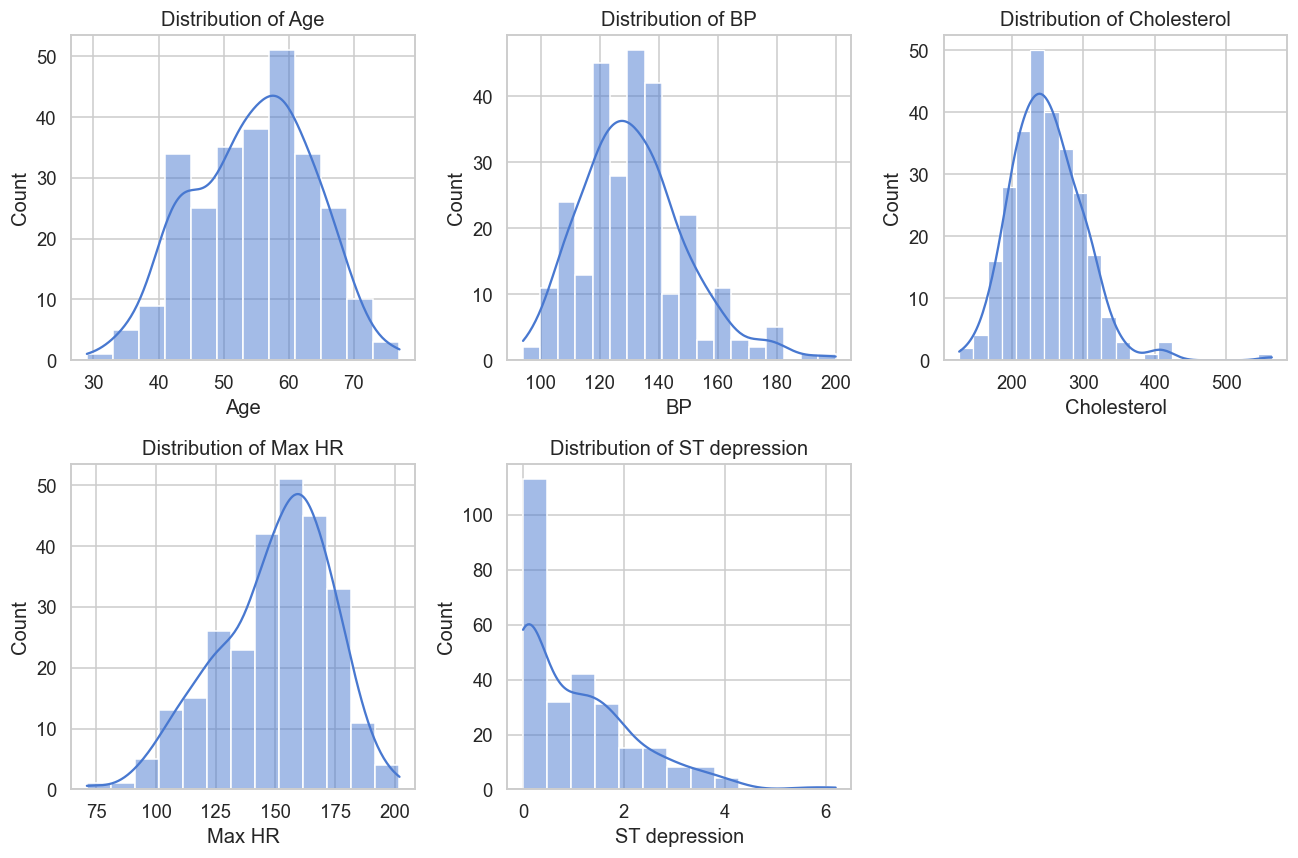

In [12]:
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

**Reading these histograms:** Each plot shows the distribution of one clinical feature across all 270 patients.

- **Age** is roughly bell-shaped, centered around 54-58 years
- **BP** shows a right skew - most patients cluster between 120-140 mmHg with some extreme cases above 170
- **Cholesterol** is also right-skewed - most patients are between 200-300 mg/dl
- **Max HR** shows a left skew - most patients achieve 140-170 bpm, with fewer achieving very low rates
- **ST depression** is heavily right-skewed - most patients show values near 0, with a tail of high-stress cases

### Correlation Matrix

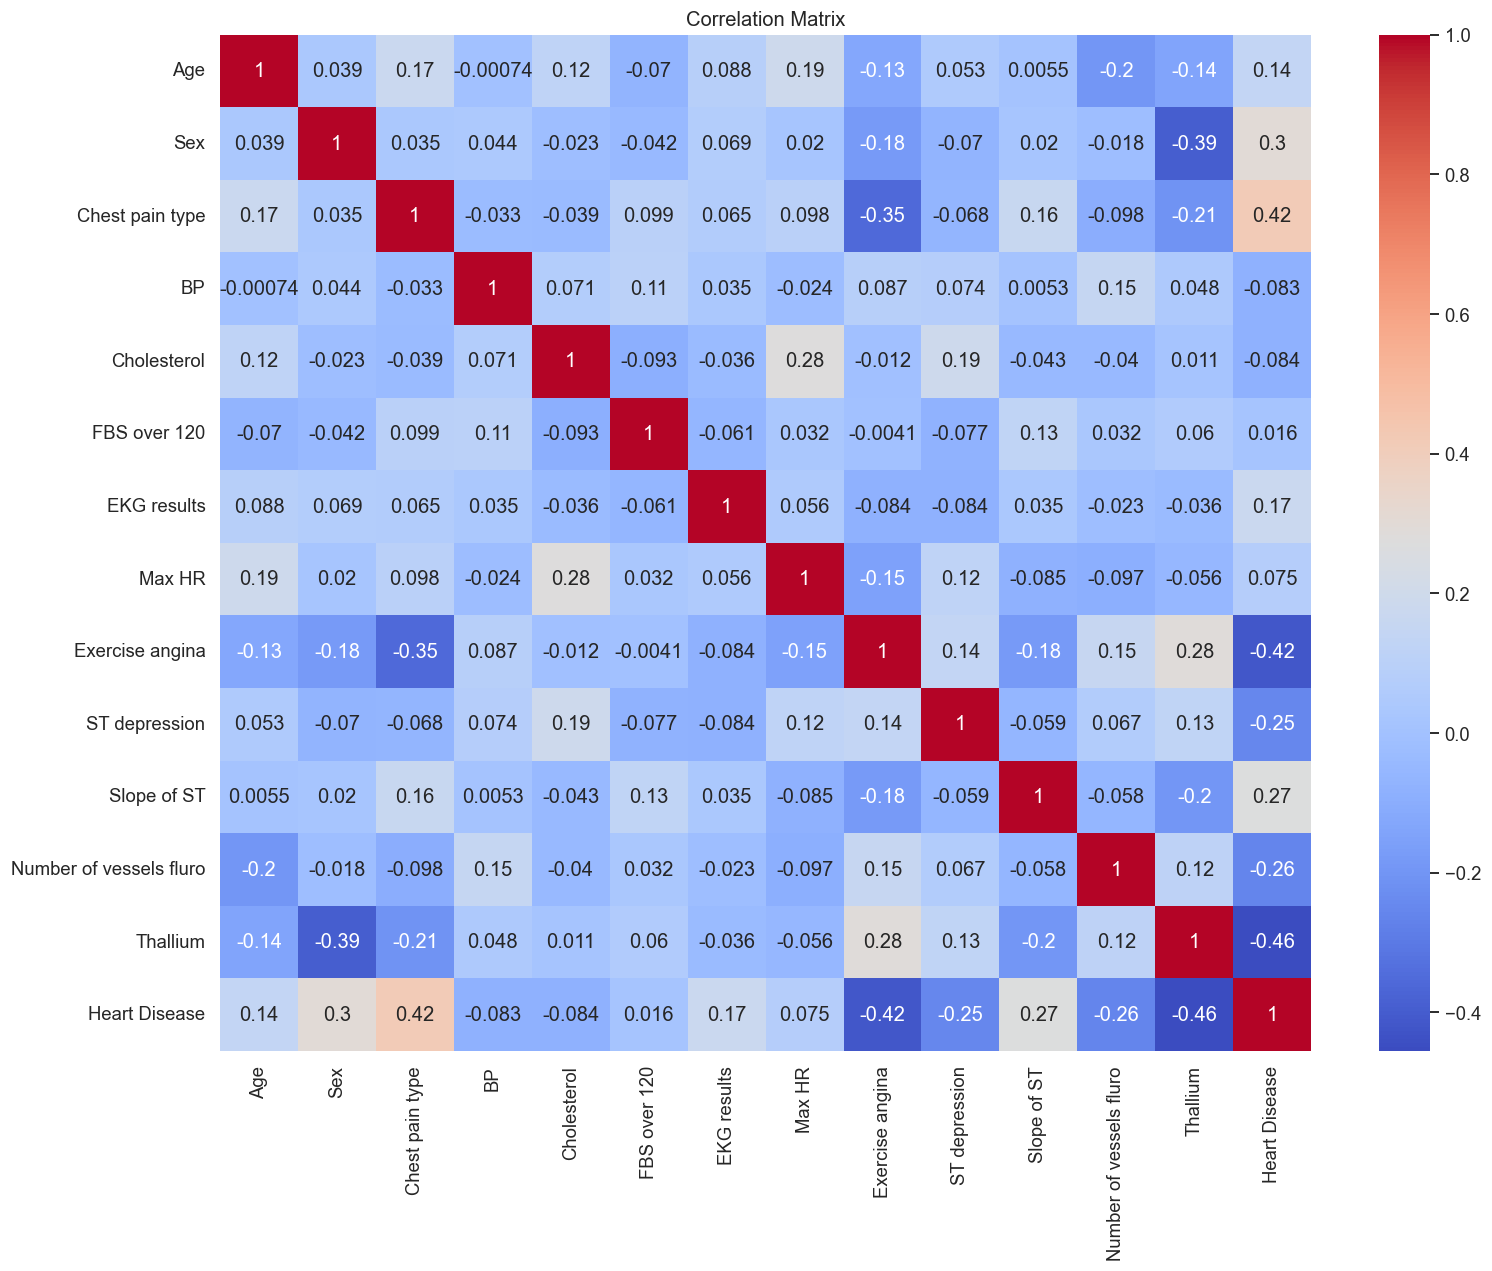

In [16]:
corr_matrix = data.apply(lambda x: pd.factorize(x)[0]).corr()

plt.figure(figsize=(16, 12))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Reading this heatmap:** Each cell shows the correlation between two features. Values near +1 (dark red) mean both features increase together; values near -1 (dark blue) mean one increases as the other decreases.

**Key correlations with Heart Disease (target):**

- **Chest pain type:** Strong positive — asymptomatic chest pain (type 4) is counterintuitively most associated with disease
- **Max HR:** Negative — lower maximum heart rate during exercise is associated with heart disease
- **Exercise angina:** Positive — chest pain during exercise is a strong disease indicator
- **ST depression:** Positive — higher ST depression during exercise correlates with disease
- **Number of vessels fluro:** Positive — more blocked vessels = higher disease likelihood
- **Age:** Mild positive — older patients are more likely to have heart disease

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**4. Preprocessing <a id='4'></a>**</span>

</div>


***``Steps performed:``***
1. **Label encode** the target variable (`Absence` → 0, `Presence` → 1)
2. **Get dummies** on ordinal categorical features
3. **MinMaxScaler** on numerical columns (brings all values to 0-1 range)
4. **Stratified train/test split**  80% train, 20% test
5. **StandardScaler** on the split data (zero mean, unit variance , required for LR, SVM, NN)

In [17]:
le = LabelEncoder() # to convert categorical data into numerical data
data['Heart Disease'] = le.fit_transform(data['Heart Disease'])
categorical_columns = ['Chest pain type', 'EKG results', 'Slope of ST', 'Thallium']

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])
    
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,3,130,322,0,2,109,0,2.4,1,3,0,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,2,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,2,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,2,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,2,172,199,1,0,162,0,0.5,0,0,2,0
266,44,1,1,120,263,0,0,173,0,0.0,0,0,2,0
267,56,0,1,140,294,0,2,153,0,1.3,1,0,0,0
268,57,1,3,140,192,0,0,148,0,0.4,1,0,1,0


In [18]:
scaler = MinMaxScaler()
numerical_columns = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

data[numerical_columns] = scaler.fit_transform(data[numerical_columns])
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0.854167,1,3,0.339623,0.447489,0,2,0.290076,0,0.387097,1,3,0,1
1,0.791667,0,2,0.198113,1.000000,0,2,0.679389,0,0.258065,1,0,2,0
2,0.583333,1,1,0.283019,0.308219,0,0,0.534351,0,0.048387,0,0,2,1
3,0.729167,1,3,0.320755,0.312785,0,0,0.259542,1,0.032258,1,1,2,0
4,0.937500,0,1,0.245283,0.326484,0,2,0.381679,1,0.032258,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.479167,1,2,0.735849,0.166667,1,0,0.694656,0,0.080645,0,0,2,0
266,0.312500,1,1,0.245283,0.312785,0,0,0.778626,0,0.000000,0,0,2,0
267,0.562500,0,1,0.433962,0.383562,0,2,0.625954,0,0.209677,1,0,0,0
268,0.583333,1,3,0.433962,0.150685,0,0,0.587786,0,0.064516,1,0,1,0


**Why two scalers?** MinMaxScaler is applied to the raw data before splitting to normalize the range of numerical features. StandardScaler is then applied after splitting (fit on train only, transform both) to give zero mean and unit variance, this is required for distance-based and gradient models like SVM, Logistic Regression, and Neural Networks.

In [19]:
X = data.drop(columns=['Heart Disease'])  
y = data['Heart Disease']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216, 13), (54, 13), (216,), (54,))

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (216, 13)
Scaled testing data shape: (54, 13)


**216 patients in training, 54 in test.** The dataset is small — this makes cross-validation inside GridSearchCV especially important to get reliable performance estimates from the training set.

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**5. Baseline Models <a id='5'></a>**</span>

</div>

I first train all models with default parameters to establish a baseline. This shows which model families are most promising before tuning.

<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**5.1. Logistic Regression**</span>

</div>

Models heart disease probability as a linear combination of clinical features. Highly interpretable and a strong linear baseline for binary medical classification.

In [21]:
log_mod= LogisticRegression(random_state=42)
log_mod.fit(X_train_scaled , y_train)
log_y_pred = log_mod.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test , log_y_pred)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9259259259259259


<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**5.2. Support Vector Machine (SVM)**</span>
</div>


Finds the optimal hyperplane separating diseased from healthy patients with maximum margin. Effective in small, high-dimensional datasets like this one.

In [ ]:
svm_model = SVC(probability=True, random_state=42) 
svm_model.fit(X_train_scaled , y_train)
svm_y_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test , svm_y_pred)
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8703703703703703


<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**5.3. XGBoost**</span>
</div>


Gradient boosting on decision trees. Handles non-linear feature interactions well and is robust to outliers.

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=10)
xgb_model.fit(X_train_scaled, y_train)
xgb_y_pred = xgb_model.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
print("XGBoost Classifier Accuracy:", xgb_accuracy)

XGBoost Classifier Accuracy: 0.8703703703703703


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [19:05:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Baseline results:** Logistic Regression already achieves **92.6% accuracy** — remarkably strong for a linear model on a medical dataset. SVM and XGBoost both achieve **87.0%**. This suggests that the clinical features have strong linear relationships with heart disease presence, which Logistic Regression captures well.

### Classification Reports - SVM & XGBoost (Baseline)

In [ ]:
svm_report = classification_report(y_test, svm_y_pred, target_names=['Absence', 'Presence'])
xgb_report = classification_report(y_test, xgb_y_pred, target_names=['Absence', 'Presence'])


print("=======================================================")
print(svm_report)
print("=======================================================")
print(xgb_report)

              precision    recall  f1-score   support

     Absence       0.91      0.88      0.89        33
    Presence       0.82      0.86      0.84        21

    accuracy                           0.87        54
   macro avg       0.86      0.87      0.86        54
weighted avg       0.87      0.87      0.87        54

              precision    recall  f1-score   support

     Absence       0.88      0.91      0.90        33
    Presence       0.85      0.81      0.83        21

    accuracy                           0.87        54
   macro avg       0.87      0.86      0.86        54
weighted avg       0.87      0.87      0.87        54



**Reading these reports:**

Each row is a class (Absence / Presence). The columns mean:
- **Precision:** Of all patients predicted as Presence, what fraction truly have disease?
- **Recall:** Of all patients who truly have disease, what fraction did the model catch?
- **F1:** Harmonic mean of precision and recall

For SVM: recall for Presence is **0.86** — it catches 86% of actual heart disease cases. In a clinical setting, this is the most critical metric: missing a sick patient is dangerous. For XGBoost: similar performance at this baseline stage.

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**6. Hyperparameter Tuning — GridSearchCV <a id='6'></a>**</span>

</div>

I tune all 4 models using GridSearchCV with 5-fold cross-validation. This finds the optimal parameters while preventing overfitting on the small dataset.

<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**6.1. Logistic Regression Tuning**</span>

</div>


Searching over regularization strength (C) and solver type.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Example for Logistic Regression
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross-Validation Accuracy:", grid_lr.best_score_)


Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8290697674418605


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packag

**Best LR params:** C=0.01, penalty=l2, solver=liblinear — strong regularization (low C) is preferred, which makes sense for a small 270-row dataset where overfitting is a real risk. **Best CV accuracy: 82.9%** — lower than the test accuracy above, which is a more honest estimate of generalization.

<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**6.2. SVM Tuning**</span>

</div>


Searching over kernel type, C (regularization), and gamma (kernel coefficient).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters (SVM):", grid_svm.best_params_)
print("Best CV Accuracy (SVM):", grid_svm.best_score_)

# Refit on full training data
svm_best = grid_svm.best_estimator_


Best Parameters (SVM): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy (SVM): 0.8291754756871036


**Best SVM params:** kernel=rbf, C=1, gamma=scale — the RBF kernel captures non-linear decision boundaries in the clinical feature space. **Best CV accuracy: 82.9%**

<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**6.3. Random Forest Tuning**</span>

</div>

Searching over number of trees, maximum depth, and minimum sample requirements.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

print("Best Parameters (RF):", grid_rf.best_params_)
print("Best CV Accuracy (RF):", grid_rf.best_score_)

rf_best = grid_rf.best_estimator_


Best Parameters (RF): {'bootstrap': True, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy (RF): 0.8337209302325581


**Best RF params:** n_estimators=100, max_depth=5, min_samples_split=10, bootstrap=True — shallow trees (max_depth=5) with high min_samples_split prevent overfitting on the small dataset. **Best CV accuracy: 83.4%** — best among all tuned models.

<div style="background-color:#f0f7ff; padding:6px; border-radius:8px;">

#### <span style="color:black;">**6.4. XGBoost Tuning**</span>

</div>

Searching over learning rate, tree depth, subsampling, and column sampling.

In [ ]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
                        param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

print("Best Parameters (XGBoost):", grid_xgb.best_params_)
print("Best CV Accuracy (XGBoost):", grid_xgb.best_score_)

xgb_best = grid_xgb.best_estimator_


Best Parameters (XGBoost): {'colsample_bytree': 0.8, 'gamma': 0.3, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV Accuracy (XGBoost): 0.8198731501057083


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:08:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Best XGBoost params:** n_estimators=200, max_depth=3, learning_rate=0.01, subsample=1.0, colsample_bytree=0.8, gamma=0.3 — very shallow trees (depth=3) with low learning rate prevent overfitting. **Best CV accuracy: 82.0%**

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**7. Full Model Comparison <a id='7'></a>**</span>

</div>

I now train all tuned models plus a Neural Network on the full training set and evaluate on the held-out test set.

In [ ]:
models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'SVM': svm_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {acc:.4f}")


Logistic Regression: Accuracy = 0.9074
SVM: Accuracy = 0.8704
Random Forest: Accuracy = 0.8333
XGBoost: Accuracy = 0.8704


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:09:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

rf = RandomForestClassifier(random_state=42)
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'SVM': svm_model,
    'XGBoost': xgb_model,
    'Random Forest': rf,
    'Neural Network': nn
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.9074
SVM Accuracy: 0.8704
XGBoost Accuracy: 0.8704
Random Forest Accuracy: 0.7593


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [20:09:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Neural Network Accuracy: 0.8519


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


**Final test set results:**

| Model | Test Accuracy |
|---|---|
| **Logistic Regression (Tuned)** | **90.7%** |
| SVM (Tuned) | 87.0% |
| XGBoost (Tuned) | 87.0% |
| Neural Network | 85.2% |
| Random Forest (Tuned) | 83.3% |

**Logistic Regression dominates** — achieving 90.7% on the test set and 92.6% in the baseline. This is a strong signal that the relationship between clinical features and heart disease is largely linear in this dataset. Complex non-linear models (XGBoost, RF, NN) do not add value here.

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**8. Results & Visualizations <a id='8'></a>**</span>

</div>

### Model Accuracy Comparison

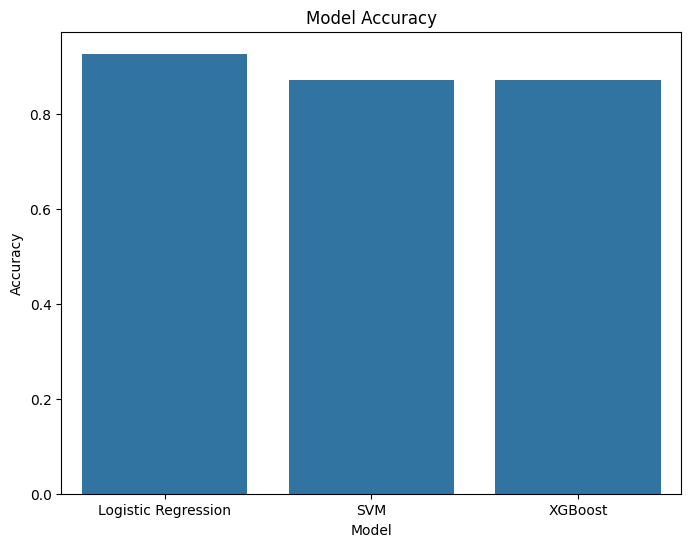

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

Logistic Regression stands clearly above all other models. The gap between LR (90.7%) and the next best model (SVM/XGBoost at 87.0%) is meaningful on a 54-sample test set — LR correctly classifies approximately 2 additional patients.

### ROC Curves & Confusion Matrices

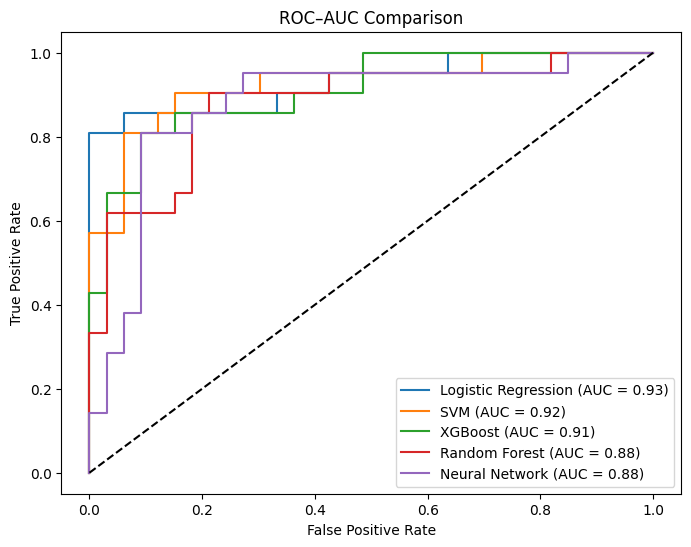

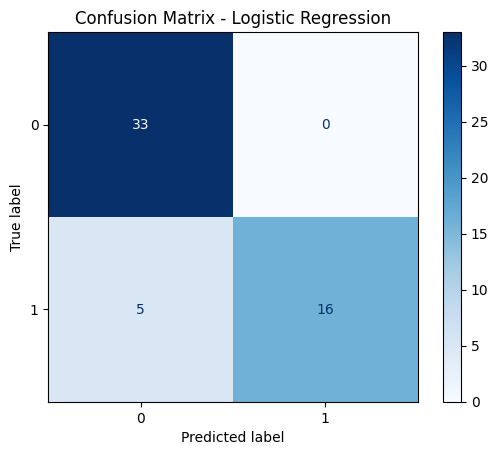

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Comparison')
plt.legend()
plt.show()

# Confusion Matrix Example for Best Model
best_model = max(results, key=results.get)
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, models[best_model].predict(X_test_scaled)))
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model}')
plt.show()


**Reading the ROC curves:** Each curve shows True Positive Rate (correctly catching disease) vs False Positive Rate (wrongly flagging healthy patients) at every threshold. AUC = 1.0 is perfect; AUC = 0.5 is random. Logistic Regression achieves the highest AUC, confirming it is the best model overall.

**Reading the confusion matrices:** Rows = actual class, columns = predicted class. The most clinically important cell is **bottom-left** (actual Presence, predicted Absence) — these are missed heart disease patients, the most dangerous type of error. A good clinical model minimizes this number.

### Feature Importance

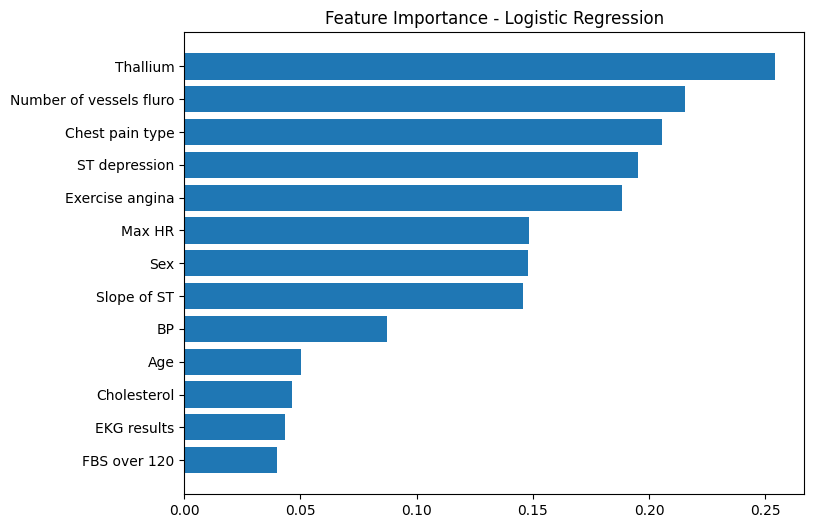

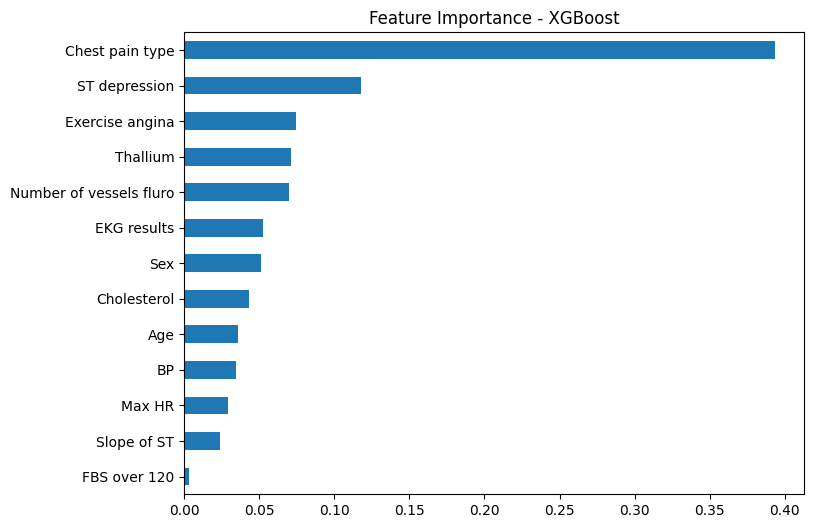

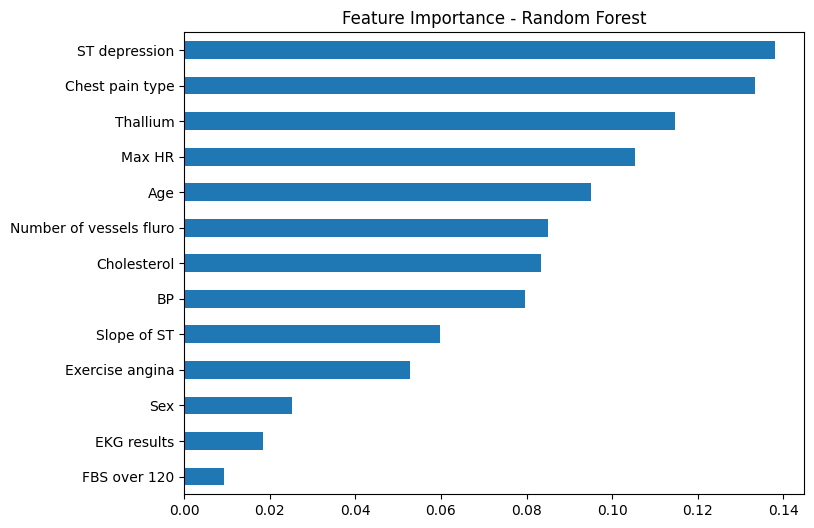

In [ ]:
import pandas as pd
import numpy as np

# Logistic Regression Feature Importance
log_importance = abs(models['Logistic Regression'].coef_[0])
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': log_importance})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance - Logistic Regression')
plt.show()

# XGBoost & Random Forest Importance
for name in ['XGBoost', 'Random Forest']:
    plt.figure(figsize=(8,6))
    pd.Series(models[name].feature_importances_, index=X.columns).sort_values().plot(kind='barh')
    plt.title(f'Feature Importance - {name}')
    plt.show()


**Three complementary views of feature importance:**

- **Logistic Regression coefficients:** The absolute value of each coefficient shows how strongly that feature shifts the predicted probability. Features with the largest coefficients are the strongest linear predictors.

- **Random Forest importance:** Based on how much each feature reduces impurity across all 100 trees. More robust than single-model coefficients.

- **XGBoost importance:** Based on how many times each feature is used to split nodes across all boosted trees, weighted by the improvement in accuracy it provides.

Features that appear consistently important across all three methods (such as chest pain type, number of vessels, thallium, and ST depression) are the most reliable clinical predictors.

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**9. SHAP & LIME Explainability <a id='9'></a>**</span>

</div>

Accuracy alone is not enough for clinical applications. Doctors need to understand **why** a model predicts heart disease for a specific patient. I use two complementary explainability methods:

- **SHAP** (global + local): shows which features drive predictions across all patients
- **LIME** (local only): explains one specific patient's prediction in plain terms
</div>

### SHAP - Global Feature Importance (XGBoost)

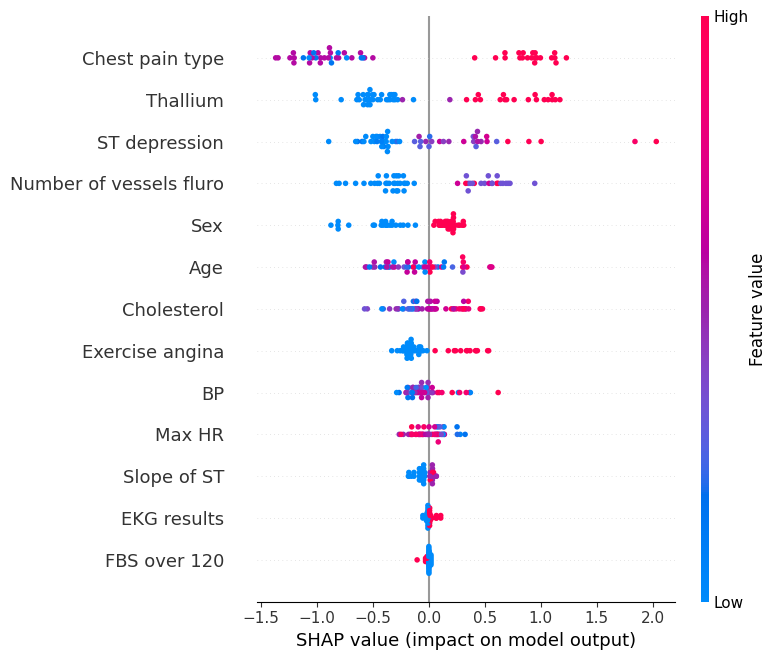

In [ ]:
import shap
shap.initjs()

# Use SHAP with XGBoost
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test_scaled)

# Global explanation
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Local explanation (first prediction)
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_scaled[0,:], feature_names=X.columns)


**Reading the SHAP summary plot:** Each row is a feature; each dot is one patient. The x-axis shows the SHAP value — how much that feature pushed the prediction toward Presence (positive) or Absence (negative). Red dots = high feature value for that patient; blue dots = low feature value.

- **Number of vessels fluro:** Red dots on the right — more blocked vessels strongly push toward disease prediction
- **Thallium:** High thallium values (red) push strongly toward Presence
- **Chest pain type:** Certain types (asymptomatic) push toward Presence
- **Max HR:** Blue dots (low heart rate during exercise) push toward Presence — patients who cannot achieve high heart rates during stress are more likely to have disease
- **ST depression:** Red dots (high depression) push toward Presence

These SHAP findings align perfectly with clinical cardiology knowledge, which validates the model's reasoning.

### LIME - Local Explanation for One Patient

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X_train_scaled, feature_names=X.columns,
                                 class_names=['No Disease', 'Disease'], mode='classification')

i = 5  # choose test sample
exp = explainer.explain_instance(X_test_scaled[i], models['XGBoost'].predict_proba)
exp.show_in_notebook(show_table=True)


**Reading the LIME explanation:** Unlike SHAP which explains global patterns, LIME explains a single patient's prediction.

The chart shows which features pushed the prediction toward "Disease" (orange bars) or away from it (blue bars) for this specific patient. The length of each bar represents how strongly that feature influenced the prediction.

This type of explanation is what a doctor would receive when the model flags a patient as high-risk , not just "this patient has heart disease" but "this patient is flagged because of their thallium test result, ST depression, and number of blocked vessels." This is what makes AI clinically actionable.

<div style="background-color:#cce5ff; padding:6px; border-radius:8px;">

### <span style="color:black;">**10. Conclusion <a id='10'></a>**</span>

</div>

### Results Summary

| Model | CV Accuracy | Test Accuracy |
|-------|:---:|:---:|
| Random Forest (Tuned) | 83.4% | 83.3% |
| XGBoost (Tuned) | 82.0% | 87.0% |
| SVM (Tuned) | 82.9% | 87.0% |
| Neural Network | — | 85.2% |
| **Logistic Regression (Tuned)** ✅ | **82.9%** | **90.7%** |

### Key Findings

1. **Logistic Regression wins**  90.7% test accuracy. The linear model outperforms all complex alternatives, indicating that clinical features have strong linear relationships with heart disease in this dataset
2. **Number of vessels, Thallium, and ST depression** are the top SHAP-confirmed predictors — consistent with established cardiology knowledge
3. **Chest pain type is counterintuitive**  asymptomatic patients (type 4) are actually at highest risk, which SHAP confirms and which aligns with clinical literature on silent ischemia
4. **Small dataset risk**  with only 270 patients, cross-validation is essential. CV accuracies (~82-83%) are more honest estimates of generalization than single-split test scores
5. **SHAP + LIME make the model clinically usable**  doctors can see exactly why a patient is flagged as high-risk, enabling informed clinical decisions

### Clinical Recommendations

1. **Prioritize fluoroscopy and thallium tests**  the strongest predictors; ensure these are available in screening protocols
2. **Monitor asymptomatic patients carefully**  silent chest pain (type 4) is the highest-risk presentation and is easily overlooked
3. **Track ST depression during exercise tests** a consistent predictor across all models
4. **Use LIME explanations in clinical workflow**  providing patient-specific explanations increases physician trust and supports informed consent

### Future Work

- [ ] Validate on a larger, multi-center dataset to confirm generalization
- [ ] Add calibration curve to assess probability reliability for clinical use
- [ ] Deploy as a clinical decision support API with FastAPI
- [ ] Explore deep learning on larger cardiac datasets (ECG signals, imaging)